# Visualize LRB Stability-Check Results

This notebook generates publication-style plots and uncertainty tables for two qutrit code families:

1. Folded qutrit `[[5,1,2]]_3` (`folded_qutrit`)
2. QGRM `[[3,1,2]]_3` (`qgrm_3_1_2`)

## What this notebook produces

- Constant-check plots (sanity behavior without threshold fits)
- Uniform-check plots (LRB and RB curves with fitted summaries)
- LRB-vs-RB mixed-fit tables with bootstrap uncertainty columns
- Pseudo-threshold trend plots against interval check index

## Recommended execution order

Run cells from top to bottom once. The notebook is organized so each section declares paths, generates plots, then summarizes uncertainty in tables.


### 0. Quick environment check

This verifies that `sdim` is available in the active kernel before any plotting utilities are imported.


In [1]:
from importlib.metadata import version
version("sdim")


'1.3.1'

### 1. Shared imports and configuration

This setup cell defines:

- Path resolution for the most recent run directory per code
- Plot-fit and threshold extraction hyperparameters
- Paper-layout plotting style controls
- Utility display functions for uncertainty tables

If you need to tune appearance or fitting behavior, this is the main place to edit.


In [2]:
from pathlib import Path
import sys
import importlib

import pandas as pd
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "lrb" / "lrb_plotting.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/lrb/lrb_plotting.py")


REPO_ROOT = find_repo_root(Path.cwd())
SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import lrb.lrb_plotting as _lrb_plotting

# Ensure notebook uses latest local edits to src/lrb/lrb_plotting.py.
importlib.reload(_lrb_plotting)

from lrb.lrb_plotting import (
    LRBPlotFitConfig,
    LRBResultsPlotter,
    LRBThresholdConfig,
    LRBPaperPlotConfig,
)


def resolve_working_folder(
    code_name: str,
    lrb_root=None,
) -> str:
    root = Path(lrb_root) if lrb_root is not None else REPO_ROOT / "LRB-experiment-data-slurm"
    code_marker = root / f"working-folder-{code_name}.txt"
    legacy_marker = root / "working-folder.txt"

    def marker_path(marker: Path):
        if not marker.exists():
            return None
        run_name = marker.read_text(encoding="utf-8").strip()
        if not run_name:
            return None
        run_path = root / run_name
        if not run_path.exists():
            return None
        return str(run_path) + "/"

    for marker in (code_marker, legacy_marker):
        maybe_path = marker_path(marker)
        if maybe_path is not None:
            return maybe_path

    candidates = sorted(
        root.glob(f"Run-*-{code_name}*"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if candidates:
        return str(candidates[0]) + "/"

    raise FileNotFoundError(
        f"No run folder found for code '{code_name}' under {root.resolve()}"
    )


fit_config = LRBPlotFitConfig(
    a_fixed=0.0,
    y_ceiling=1.0,
    min_fit_points_lrb=2,
    min_fit_points_rb=3,
    f_min=1e-8,
    f_max=1.0000000,
)

threshold_config = LRBThresholdConfig(
    tol=5e-4,
    require_consecutive=2,
    ignore_first_n=3,
    err_floor=2e-3,
    tail_min_prefix=6,
    tail_drop_tol_abs=0.01,
    tail_drop_tol_rel=0.25,
    p_min=None,
    p_max=None,
    min_lrb_n_points_keep=0,
    min_rb_n_points_keep=0,
    zoom_half_window_points=4,
    zoom_pad_frac=0.25,
    min_zoom_span=0.01,
    p_window_before_points=8,
    p_window_after_points=5,
    min_points_in_view=6,
    view_pad_frac=0.15,
    bootstrap_reps_error=500,
    bootstrap_reps_threshold=1000,
    bootstrap_ci_level=0.68,
    bootstrap_use_sem=True,
    bootstrap_seed=12345,
    paper_mode=True,
    paper_cols=2,
    paper_panel_width_in=3.2,
    paper_panel_height_in=2.5,
)

# Shared check ranges for all multi-check plotting/table methods.
const_check_min = 0
const_check_max = 0
unif_check_min = 1
unif_check_max = 22

# Optional pseudo-threshold fit controls.
pseudo_do_fit = False
pseudo_fit_model = "exp"  # or "poly"
pseudo_fit_degree = 1


paper_plot_config = LRBPaperPlotConfig(
    enabled=True,
    column_layout="double",
    rows_per_page=3,
    pairs_per_row=2,
    num_prob_samples=6,
    prob_sample_indices=(0, 3, 6, 10, 13, 15),
    row_height_in=1.6,
    panel_title_fontsize=7.0,
    axis_label_fontsize=6.6,
    tick_fontsize=6.0,
    legend_fontsize=5.7,
    line_width=0.85,
    marker_size=2.6,
    errorbar_capsize=1.2,
    show_legend_first_row_only=False,
    compact_fit_legend=True,
    legend_on_rejected_panel=True,
)

def show_error_rate_uncertainty_table(table_csv: str, label: str) -> pd.DataFrame:
    frame = pd.read_csv(table_csv)
    needed = [
        "check_num",
        "p",
        "lrb_error_rate",
        "lrb_error_rate_ci_low",
        "lrb_error_rate_ci_high",
        "rb_error_rate",
        "rb_error_rate_ci_low",
        "rb_error_rate_ci_high",
    ]
    missing = [c for c in needed if c not in frame.columns]
    if missing:
        raise ValueError(
            f"Missing uncertainty columns in {table_csv}: {missing}. "
            "Re-run the table generation cell."
        )

    view = frame[needed].copy()
    view["lrb_unc_minus"] = view["lrb_error_rate"] - view["lrb_error_rate_ci_low"]
    view["lrb_unc_plus"] = view["lrb_error_rate_ci_high"] - view["lrb_error_rate"]
    view["rb_unc_minus"] = view["rb_error_rate"] - view["rb_error_rate_ci_low"]
    view["rb_unc_plus"] = view["rb_error_rate_ci_high"] - view["rb_error_rate"]
    view = view.sort_values(["check_num", "p"]).reset_index(drop=True)

    print(f"[{label}] error-rate uncertainty table")
    display(view)
    return view

def show_pseudo_threshold_uncertainty_table(
    summary_csv: str,
    label: str,
    check_min=None,
    check_max=None,
) -> pd.DataFrame:
    frame = pd.read_csv(summary_csv)
    needed = ["check_num", "threshold_p"]
    missing = [c for c in needed if c not in frame.columns]
    if missing:
        raise ValueError(
            f"Missing pseudo-threshold columns in {summary_csv}: {missing}. "
            "Re-run threshold generation first."
        )

    view = frame.copy()
    if check_min is not None:
        view = view[view["check_num"] >= int(check_min)]
    if check_max is not None:
        view = view[view["check_num"] <= int(check_max)]
    view = view[view["threshold_p"].notna()].copy()

    keep = ["check_num", "threshold_p"]
    has_std = "threshold_p_std_boot" in view.columns
    has_ci = (
        "threshold_p_ci_low" in view.columns
        and "threshold_p_ci_high" in view.columns
    )
    if has_std:
        keep.append("threshold_p_std_boot")
    if has_ci:
        keep.extend(["threshold_p_ci_low", "threshold_p_ci_high"])

    table = view[keep].copy()
    if has_ci:
        table["threshold_unc_minus"] = (
            table["threshold_p"] - table["threshold_p_ci_low"]
        )
        table["threshold_unc_plus"] = (
            table["threshold_p_ci_high"] - table["threshold_p"]
        )
    elif has_std:
        table["threshold_unc_minus"] = table["threshold_p_std_boot"]
        table["threshold_unc_plus"] = table["threshold_p_std_boot"]
    else:
        raise ValueError(
            f"No pseudo-threshold uncertainty columns found in {summary_csv}."
        )

    table = table.sort_values(["check_num"]).reset_index(drop=True)
    print(f"[{label}] pseudo-threshold uncertainty table")
    display(table)
    return table




## Folded qutrit `[[5,1,2]]_3` (`folded_qutrit`)

This section runs the complete plotting and threshold workflow on the folded-qutrit dataset.

Interpretation focus:

- Whether LRB and RB error-rate trends separate across checks
- How stable pseudo-threshold estimates remain across interval-check index


### 2. Build folded-qutrit plotter

The next cell resolves the active run folder and constructs a `LRBResultsPlotter` instance with the shared fit configuration.


In [3]:
folded_working_folder = resolve_working_folder("folded_qutrit")
print(f"Folded working folder: {folded_working_folder}")

folded_plotter = LRBResultsPlotter(
    working_folder=folded_working_folder,
    fit_config=fit_config,
)


Folded working folder: c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/


### 2.1 Constant-check plots (folded qutrit)

Generates constant-check summary panels. These are primarily diagnostic and are useful for catching obvious anomalies before threshold analysis.


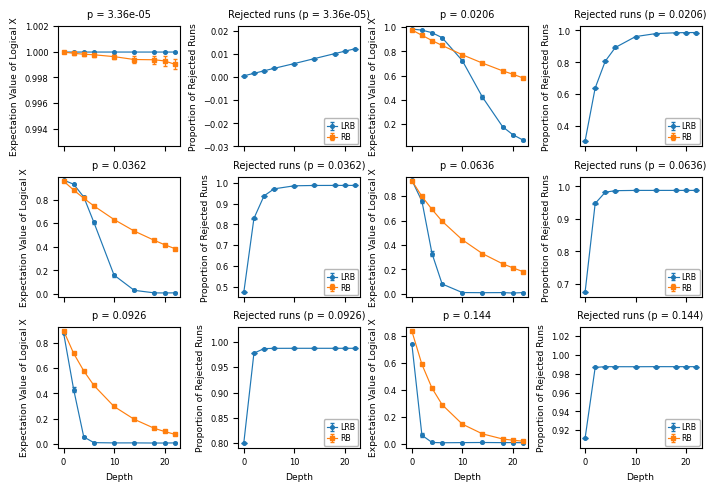

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\const-0-Summary-Graph-NoFit.pdf
Generated 1 folded constant-check plots (no fits).


In [4]:
folded_const_outputs = folded_plotter.plot_all_const_checks(
    show=True,
    check_min=const_check_min,
    check_max=const_check_max,
    paper_config=paper_plot_config,
)
print(
    f"Generated {len(folded_const_outputs)} folded constant-check plots (no fits)."
)


### 2.2 Uniform-check plots (folded qutrit)

Generates uniform-check panels with LRB/RB behavior across the configured check range.

Use these plots to visually confirm trend smoothness before trusting fit-derived quantities.


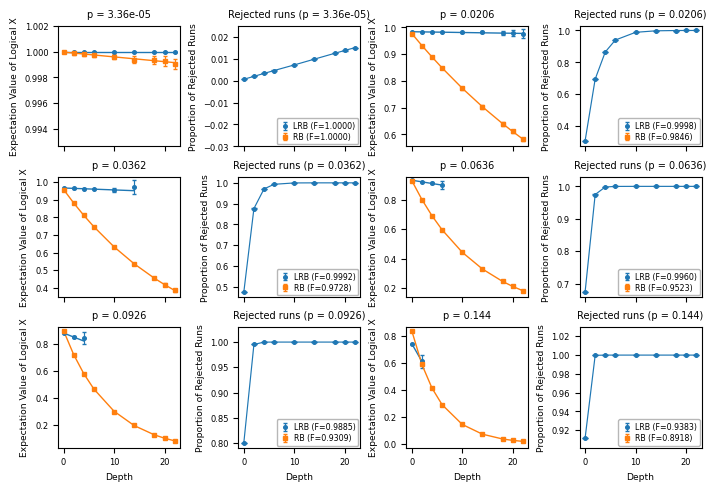

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\unif-1-Summary-Graph-Fit.pdf


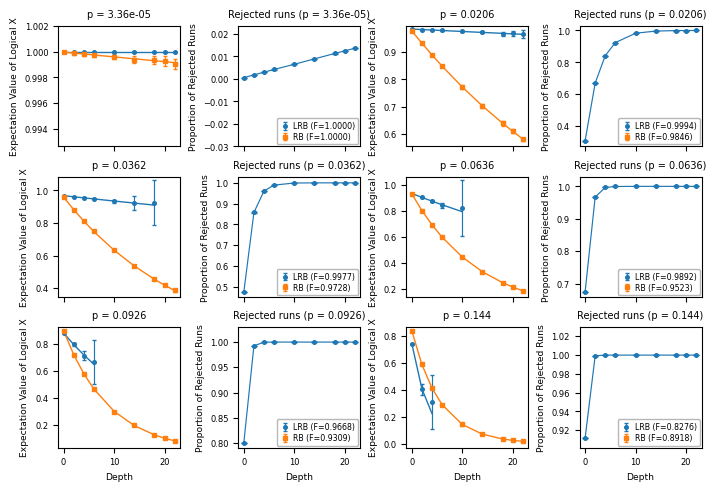

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\unif-2-Summary-Graph-Fit.pdf


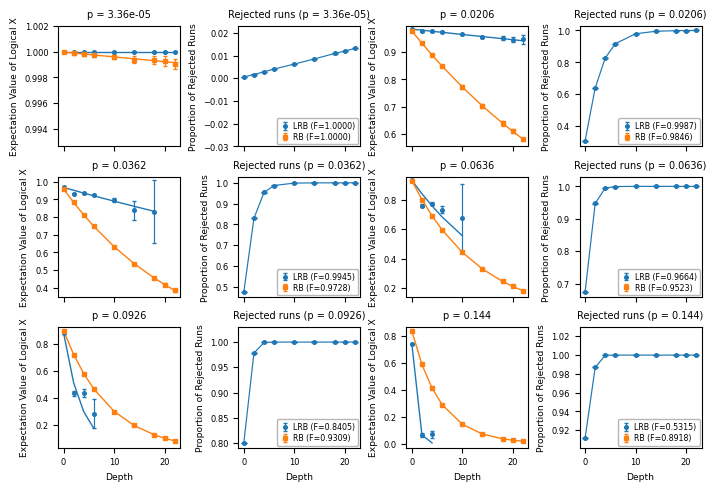

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\unif-3-Summary-Graph-Fit.pdf


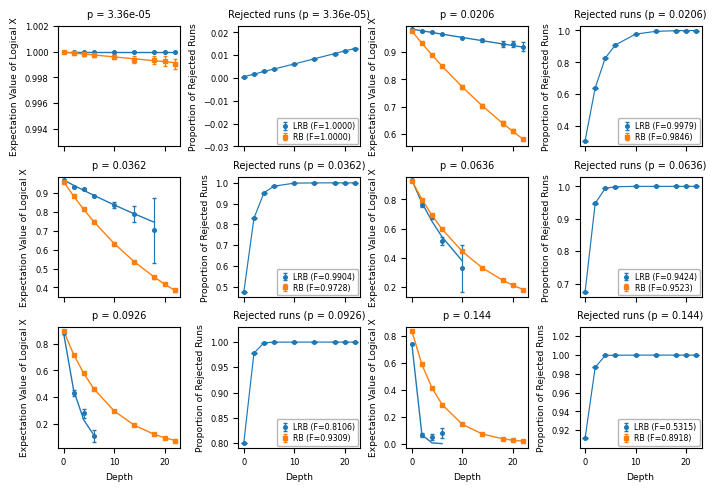

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\unif-4-Summary-Graph-Fit.pdf
Generated 4 folded uniform-check plots (with fits).


In [5]:
folded_unif_outputs = folded_plotter.plot_all_unif_checks(
    show=True,
    check_min=unif_check_min,
    check_max=4,
    paper_config=paper_plot_config,
)
print(f"Generated {len(folded_unif_outputs)} folded uniform-check plots (with fits).")


### 2.3 Threshold summaries and uncertainty tables (folded qutrit)

This block:

1. Builds mixed-fit LRB-vs-RB tables
2. Produces threshold summary plots
3. Displays bootstrap uncertainty for error rates and pseudo-thresholds

The two returned CSV paths are the main machine-readable outputs for downstream analysis.


[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\unif_lrb_vs_rb_table_all_mixed_fits.csv
[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\unif-1-lrb-vs-rb-table-mixed-fits.csv
[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\unif-2-lrb-vs-rb-table-mixed-fits.csv
[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\unif-3-lrb-vs-rb-table-mixed-fits.csv
[OK] wrote c:\

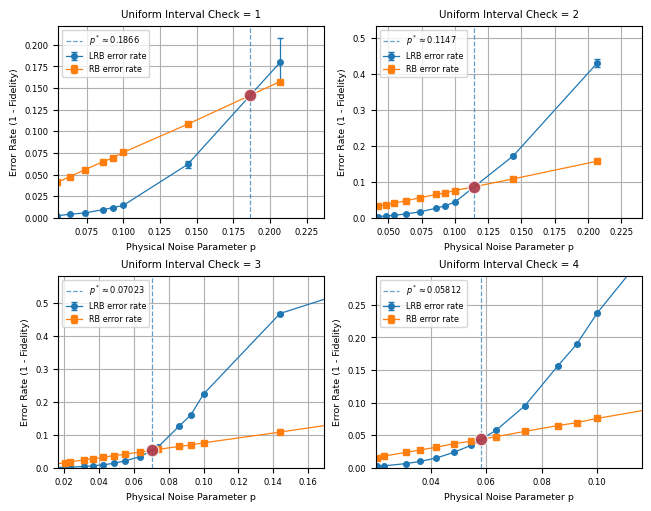

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\unif-threshold-error-vs-p-paper-grid.pdf
[THRESHOLD] Uniform Interval Check = 1: p* = 0.186611 +- 0.0123
[THRESHOLD] Uniform Interval Check = 2: p* = 0.114679 +- 0.000768
[THRESHOLD] Uniform Interval Check = 3: p* = 0.0702313 +- 0.000258
[THRESHOLD] Uniform Interval Check = 4: p* = 0.0581166 +- 0.000202
[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\unif_thresholds_summary_monotone_trim_zoom_pwindow.csv
[folded_qutrit] error-rate uncertainty table


,check_num,p,lrb_error_rate,lrb_error_rate_ci_low,lrb_error_rate_ci_high,rb_error_rate,rb_error_rate_ci_low,rb_error_rate_ci_high,lrb_unc_minus,lrb_unc_plus,rb_unc_minus,rb_unc_plus
0,1,0.000034,0.000000e+00,0.000000,0.000000e+00,0.000001,1.057654e-06,0.009275,0.000000e+00,0.000000e+00,2.093418e-07,0.009273
1,1,0.000616,1.333333e-07,0.000000,2.680000e-07,0.000877,6.212260e-07,0.003086,1.333333e-07,1.346667e-07,8.767191e-04,0.002209
2,1,0.011288,5.459454e-05,0.000052,5.696830e-05,0.008480,7.803799e-03,0.009129,2.777100e-06,2.373763e-06,6.766012e-04,0.000649
3,1,0.020613,1.945972e-04,0.000185,2.041450e-04,0.015387,1.497767e-02,0.015894,9.952539e-06,9.547837e-06,4.094693e-04,0.000507
4,1,0.023357,2.844303e-04,0.000272,2.951142e-04,0.017922,1.750487e-02,0.018346,1.236402e-05,1.068396e-05,4.170270e-04,0.000424
...,...,...,...,...,...,...,...,...,...,...,...,...
391,22,0.092552,2.992229e-01,0.298300,3.001488e-01,0.069082,6.877805e-02,0.069399,9.231147e-04,9.258240e-04,3.040853e-04,0.000316
392,22,0.100000,3.182960e-01,0.317208,3.195616e-01,0.075670,7.538304e-02,0.076016,1.087659e-03,1.265643e-03,2.868267e-04,0.000346
393,22,0.143845,4.622981e-01,0.459196,4.657648e-01,0.108198,1.077836e-01,0.108564,3.101931e-03,3.466709e-03,4.148267e-04,0.000366
394,22,0.206914,5.741653e-01,0.570588,5.787779e-01,0.157501,1.569391e-01,0.158011,3.577216e-03,4.612587e-03,5.622187e-04,0.000510


[folded_qutrit] pseudo-threshold uncertainty table


,check_num,threshold_p,threshold_p_std_boot,threshold_p_ci_low,threshold_p_ci_high,threshold_unc_minus,threshold_unc_plus
0,1,0.186611,0.012320,0.174779,0.206715,0.011832,0.020104
1,2,0.114679,0.000768,0.113994,0.115536,0.000685,0.000857
2,3,0.070231,0.000258,0.069971,0.070488,0.000260,0.000257
3,4,0.058117,0.000202,0.057927,0.058317,0.000190,0.000201


('c:\\Users\\Sohan XPS17\\OneDrive - University of California, Davis\\Documents\\UC Davis\\Kim Group\\LBNL\\LRB-Simulations-sdim\\LRB-experiment-data-slurm\\Run-2026-02-18-19-45-04-folded_qutrit/results\\plots\\unif_lrb_vs_rb_table_all_mixed_fits.csv',
 'c:\\Users\\Sohan XPS17\\OneDrive - University of California, Davis\\Documents\\UC Davis\\Kim Group\\LBNL\\LRB-Simulations-sdim\\LRB-experiment-data-slurm\\Run-2026-02-18-19-45-04-folded_qutrit/results\\plots\\unif_thresholds_summary_monotone_trim_zoom_pwindow.csv')

In [6]:
folded_table_csv = folded_plotter.build_unif_lrb_vs_rb_table_mixed_fits(
    write_per_check_tables=True,
    check_min=unif_check_min,
    check_max=unif_check_max,
    bootstrap_reps=threshold_config.bootstrap_reps_error,
    bootstrap_ci_level=threshold_config.bootstrap_ci_level,
    bootstrap_use_sem=threshold_config.bootstrap_use_sem,
    bootstrap_seed=threshold_config.bootstrap_seed,
)
folded_summary_csv = folded_plotter.plot_all_unif_threshold_graphs(
    threshold_config=threshold_config,
    table_csv_path=folded_table_csv,
    show=True,
    check_min=unif_check_min,
    check_max=4,
)

folded_uncertainty_table = show_error_rate_uncertainty_table(
    folded_table_csv,
    label="folded_qutrit",
)
folded_pseudo_threshold_table = show_pseudo_threshold_uncertainty_table(
    folded_summary_csv,
    label="folded_qutrit",
    check_min=unif_check_min,
    check_max=unif_check_max,
)

folded_table_csv, folded_summary_csv


### 2.4 Pseudo-threshold trend vs interval check (folded qutrit)

This produces a focused pseudo-threshold trend plot. Optional fitting is controlled by `pseudo_do_fit`, `pseudo_fit_model`, and `pseudo_fit_degree`.


[PSEUDO] Uniform Interval Check = 1: p* = 0.186611 +- 0.0123
[PSEUDO] Uniform Interval Check = 2: p* = 0.114679 +- 0.000768
[PSEUDO] Uniform Interval Check = 3: p* = 0.0702313 +- 0.000258
[PSEUDO] Uniform Interval Check = 4: p* = 0.0581166 +- 0.000202
[FIT] fit disabled by do_fit=False.


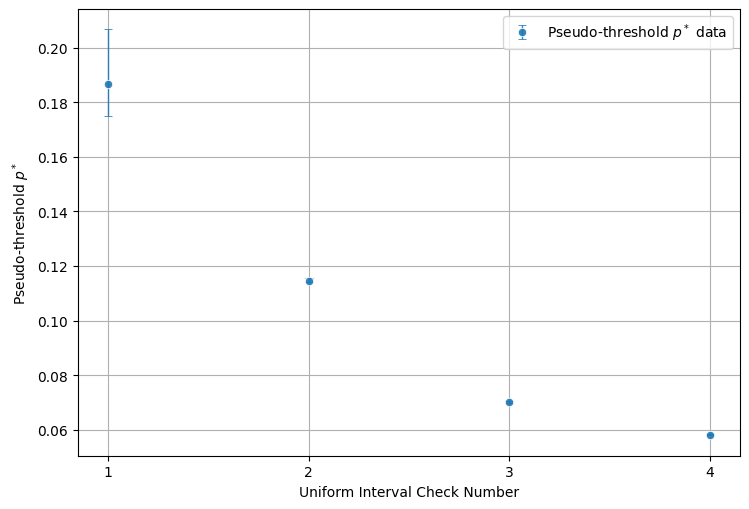

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-04-folded_qutrit/results\plots\unif-1-to-4-pseudo-threshold-vs-interval-check-fit.pdf


'c:\\Users\\Sohan XPS17\\OneDrive - University of California, Davis\\Documents\\UC Davis\\Kim Group\\LBNL\\LRB-Simulations-sdim\\LRB-experiment-data-slurm\\Run-2026-02-18-19-45-04-folded_qutrit/results\\plots\\unif-1-to-4-pseudo-threshold-vs-interval-check-fit.pdf'

In [7]:
folded_pseudo_fit_pdf = folded_plotter.plot_unif_pseudo_thresholds_vs_interval_check(
    check_min=unif_check_min,
    check_max=4,
    do_fit=pseudo_do_fit,
    fit_model=pseudo_fit_model,
    fit_degree=pseudo_fit_degree,
    paper_mode=paper_plot_config.enabled,
    show=True,
)

folded_pseudo_fit_pdf


## QGRM `[[3,1,2]]_3` (`qgrm_3_1_2`)

This section repeats the exact same workflow for the QGRM code so the outputs are directly comparable with folded qutrit.

Interpretation focus:

- Relative threshold location and uncertainty width vs folded qutrit
- Consistency of fit quality across the same check range


### 3. Build QGRM plotter

From here onward, the same pipeline is reused for QGRM to enable like-for-like comparison with folded qutrit.


In [8]:
qgrm_working_folder = resolve_working_folder("qgrm_3_1_2")
print(f"QGRM working folder: {qgrm_working_folder}")

qgrm_plotter = LRBResultsPlotter(
    working_folder=qgrm_working_folder,
    fit_config=fit_config,
)


QGRM working folder: c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/


### 3.1 Constant-check plots (QGRM)

Creates QGRM constant-check diagnostic panels.


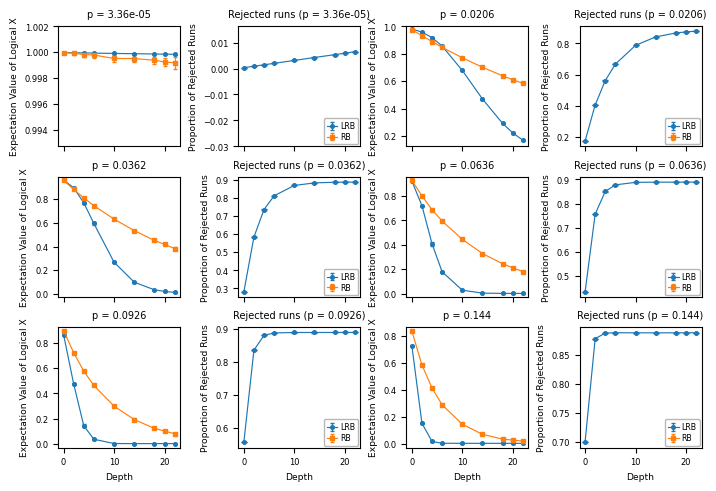

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\const-0-Summary-Graph-NoFit.pdf
Generated 1 QGRM constant-check plots (no fits).


In [9]:
qgrm_const_outputs = qgrm_plotter.plot_all_const_checks(
    show=True,
    check_min=const_check_min,
    check_max=const_check_max,
    paper_config=paper_plot_config,
)
print(
    f"Generated {len(qgrm_const_outputs)} QGRM constant-check plots (no fits)."
)

### 3.2 Uniform-check plots (QGRM)

Creates QGRM uniform-check panels across the same check window used above.


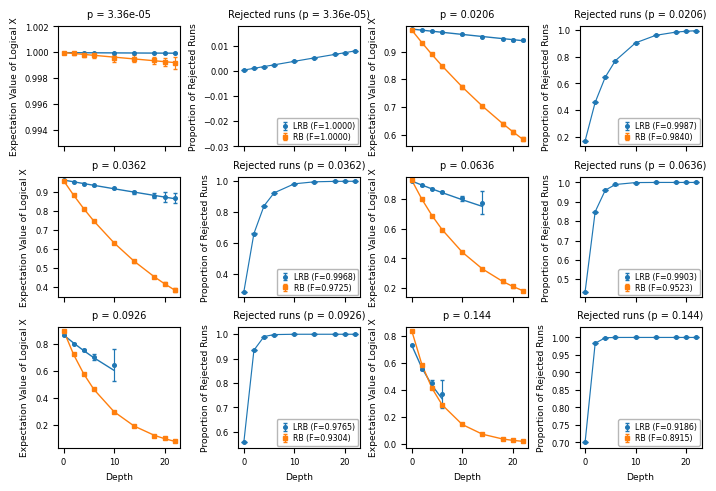

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-1-Summary-Graph-Fit.pdf


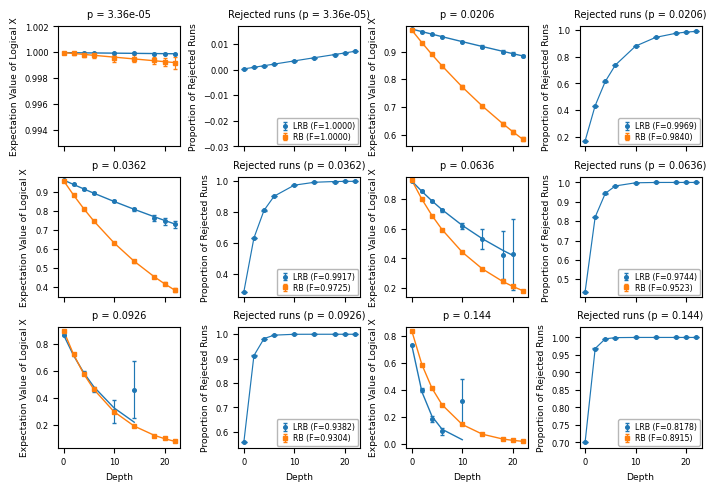

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-2-Summary-Graph-Fit.pdf


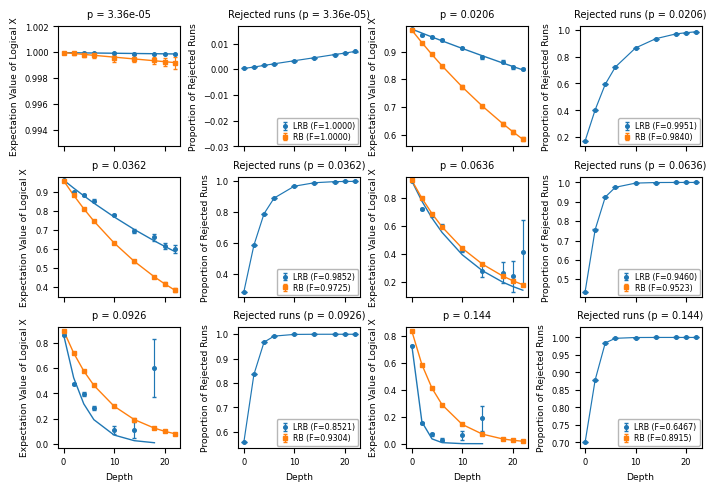

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-3-Summary-Graph-Fit.pdf


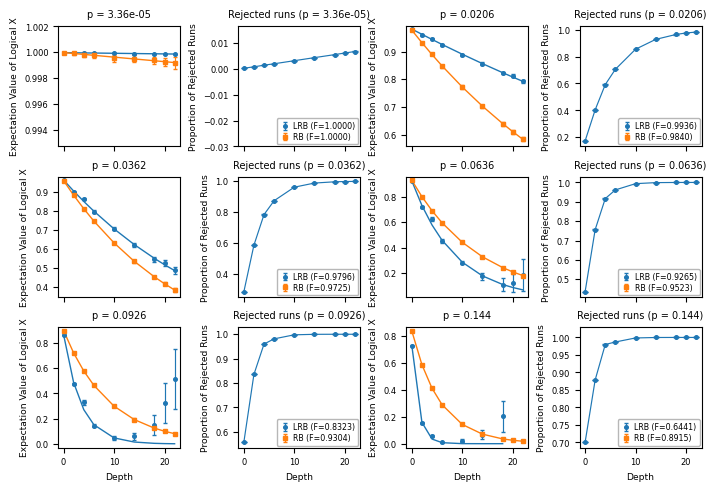

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-4-Summary-Graph-Fit.pdf


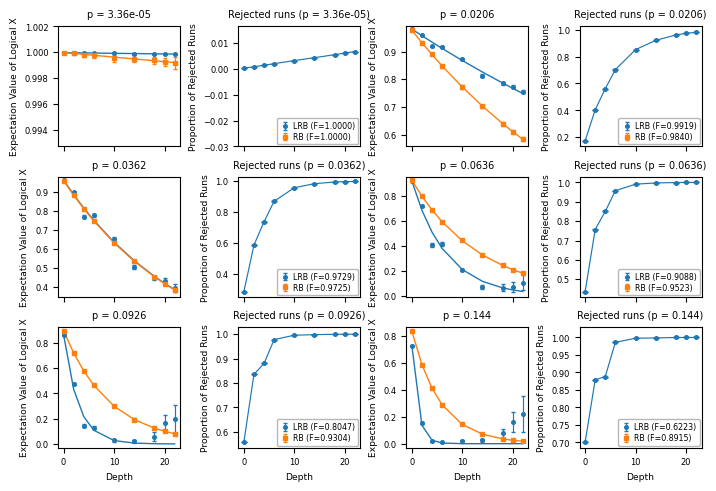

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-5-Summary-Graph-Fit.pdf


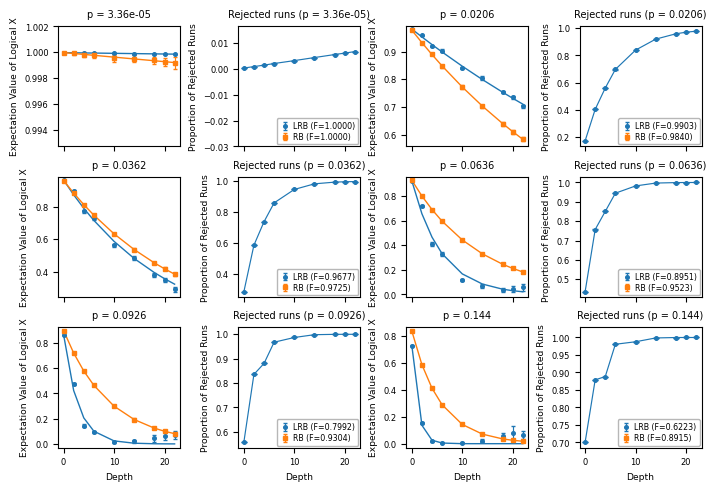

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-6-Summary-Graph-Fit.pdf


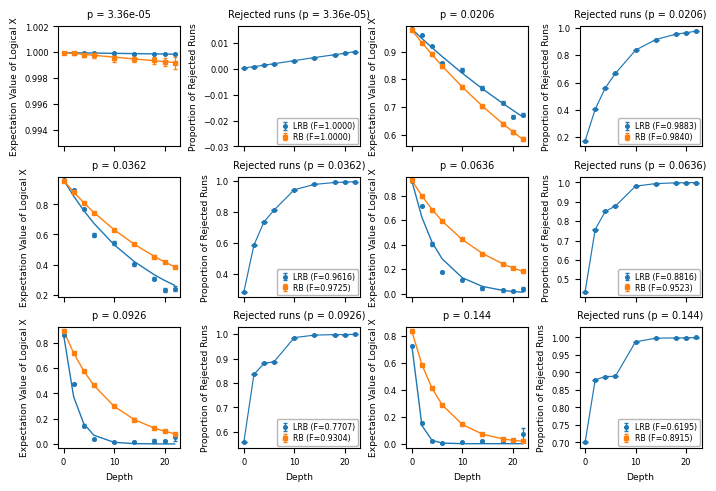

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-7-Summary-Graph-Fit.pdf


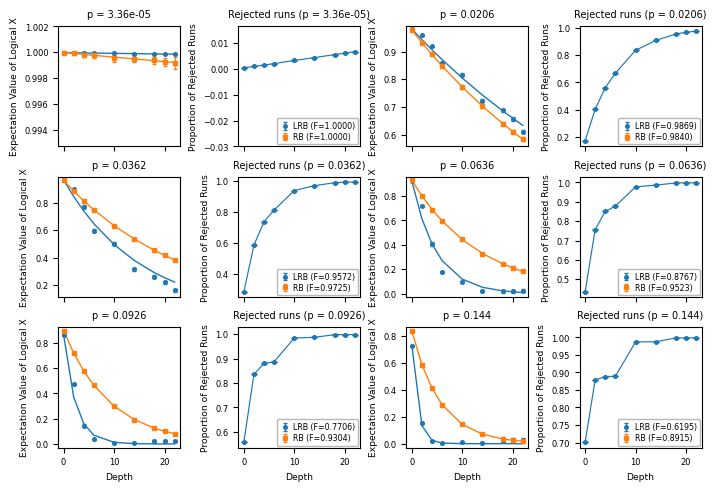

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-8-Summary-Graph-Fit.pdf


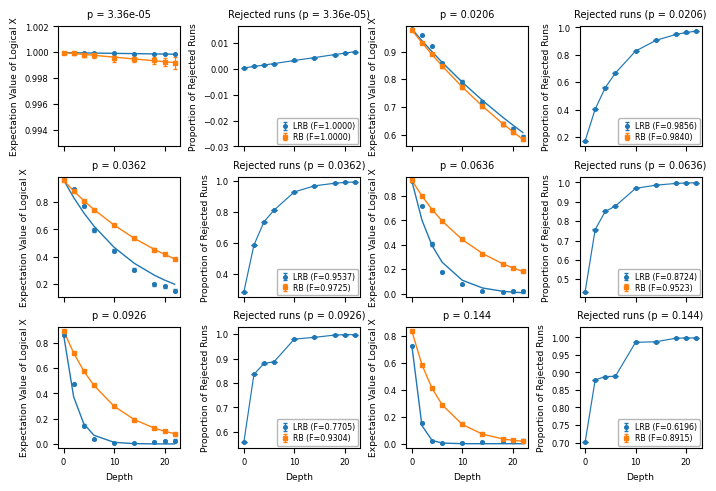

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-9-Summary-Graph-Fit.pdf


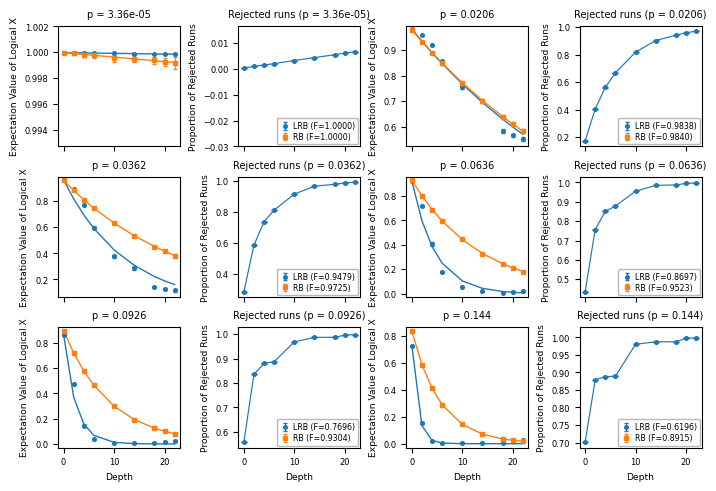

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-10-Summary-Graph-Fit.pdf


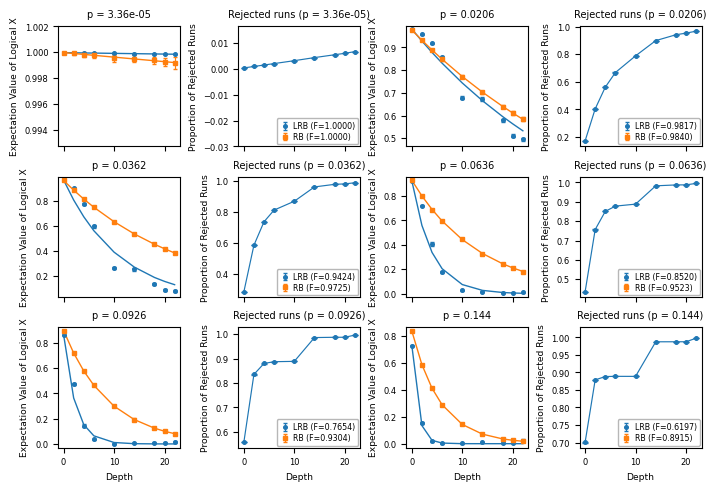

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-11-Summary-Graph-Fit.pdf


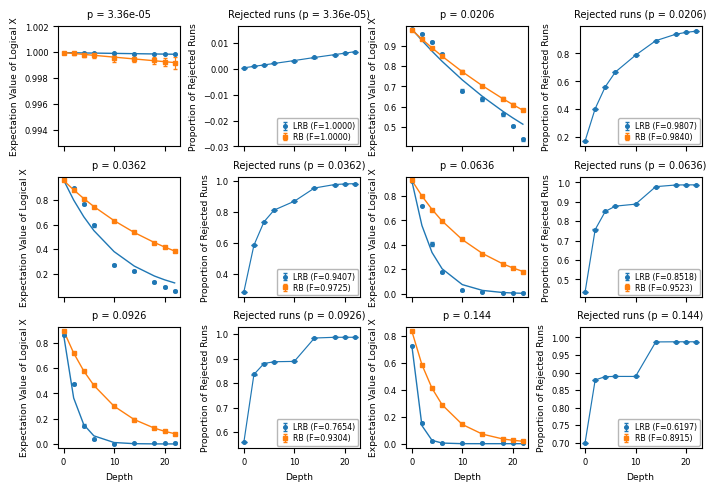

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-12-Summary-Graph-Fit.pdf


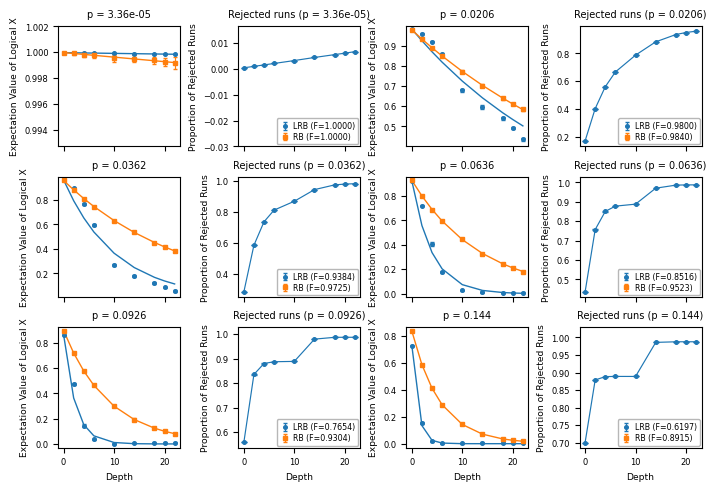

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-13-Summary-Graph-Fit.pdf


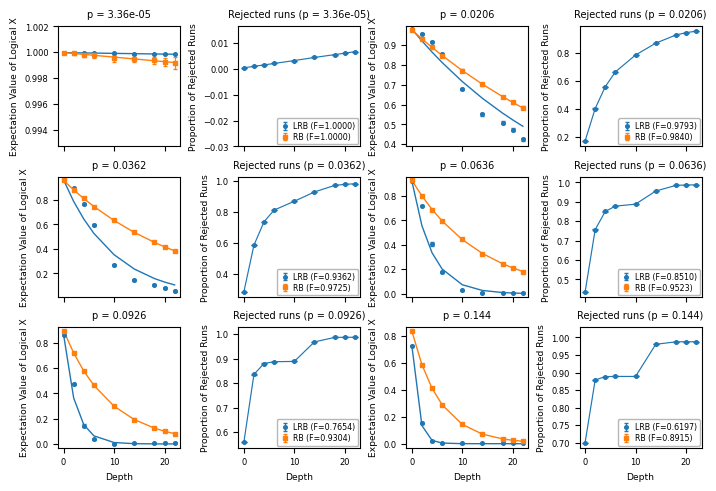

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-14-Summary-Graph-Fit.pdf


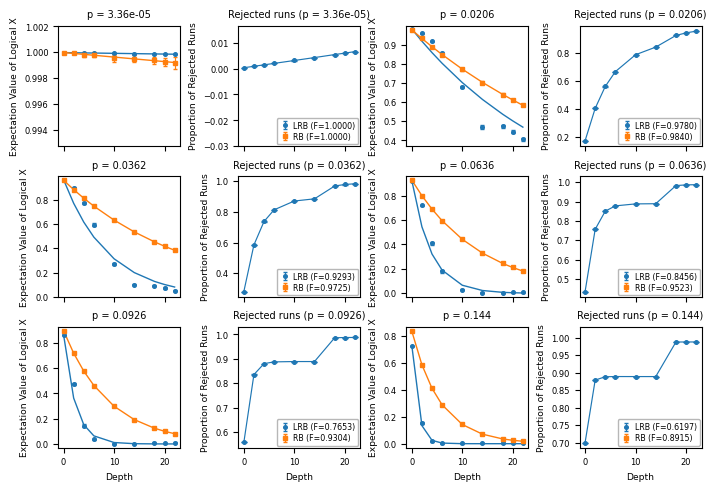

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-15-Summary-Graph-Fit.pdf


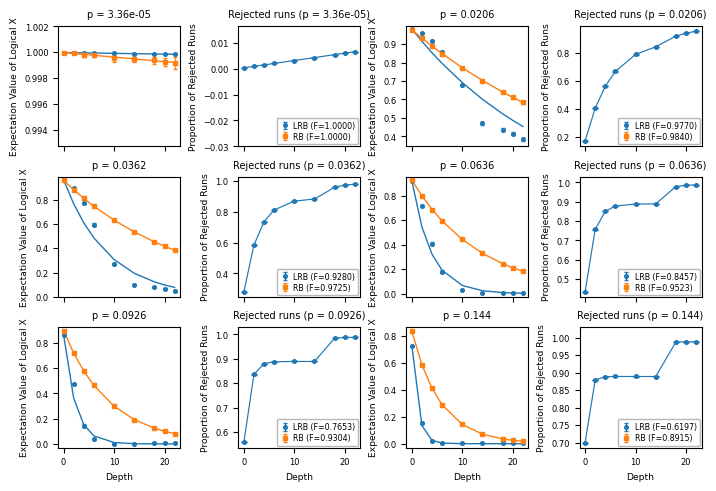

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-16-Summary-Graph-Fit.pdf


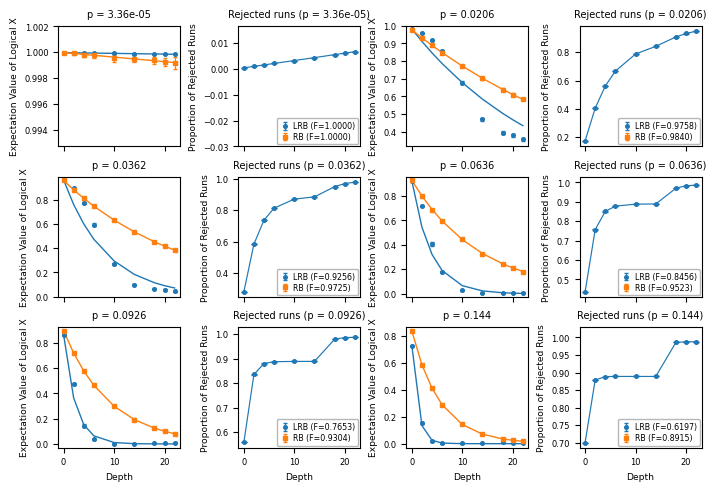

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-17-Summary-Graph-Fit.pdf


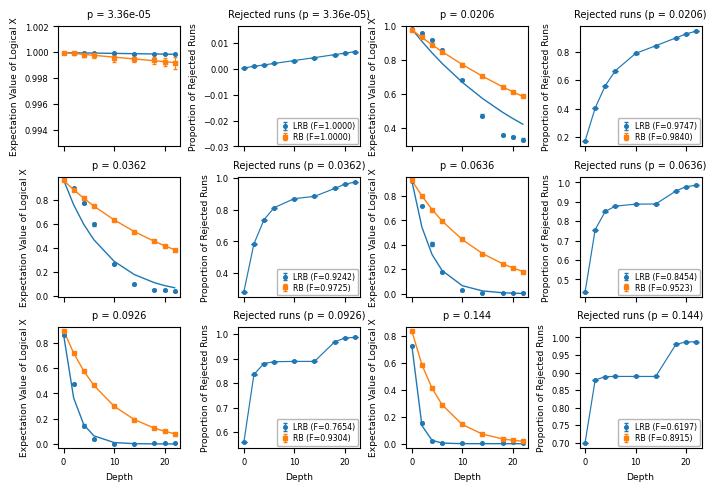

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-18-Summary-Graph-Fit.pdf


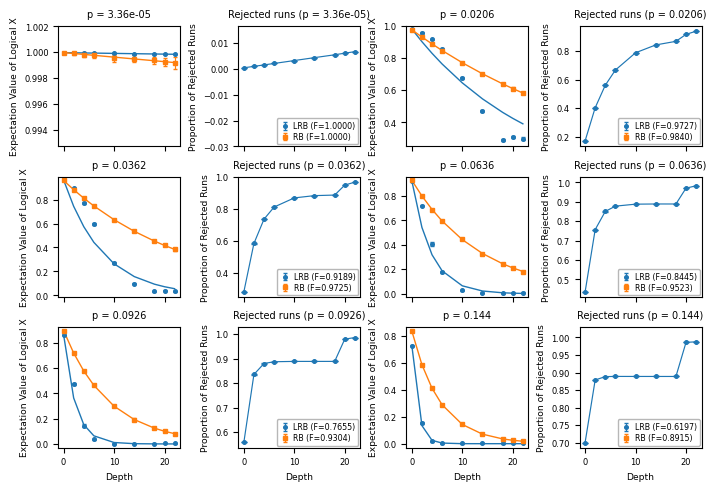

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-19-Summary-Graph-Fit.pdf


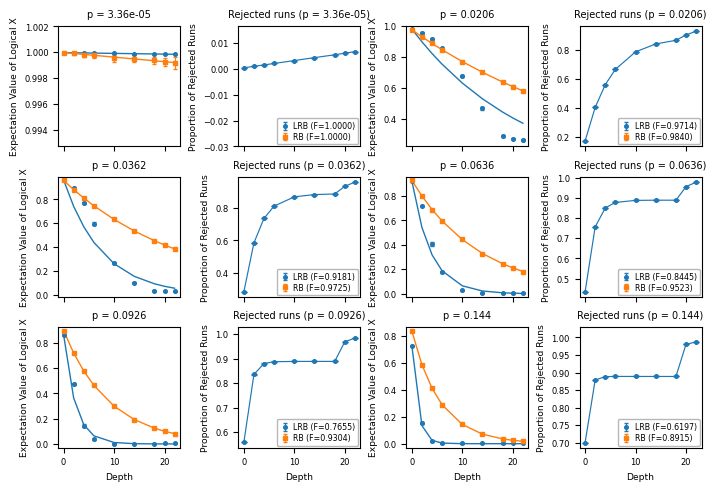

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-20-Summary-Graph-Fit.pdf


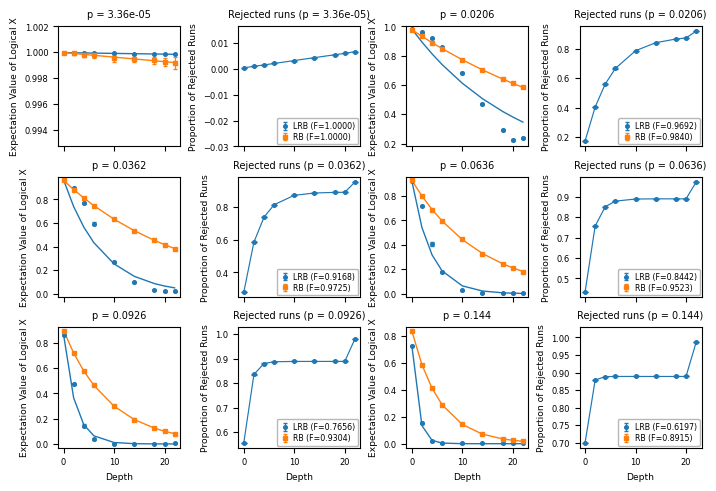

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-21-Summary-Graph-Fit.pdf


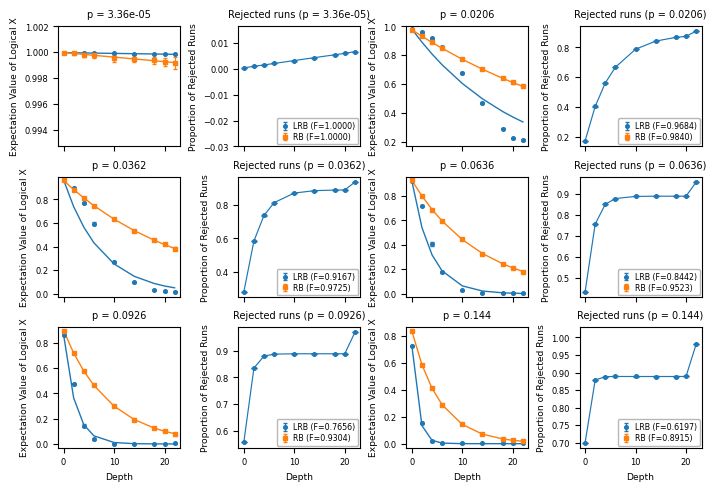

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-22-Summary-Graph-Fit.pdf
Generated 22 QGRM uniform-check plots (with fits).


In [10]:
qgrm_unif_outputs = qgrm_plotter.plot_all_unif_checks(
    show=True,
    check_min=unif_check_min,
    check_max=unif_check_max,
    paper_config=paper_plot_config,
)
print(f"Generated {len(qgrm_unif_outputs)} QGRM uniform-check plots (with fits).")

### 3.3 Threshold summaries and uncertainty tables (QGRM)

Repeats table generation, threshold visualization, and uncertainty extraction for QGRM.

Compare these outputs directly against folded qutrit to assess relative robustness.


[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif_lrb_vs_rb_table_all_mixed_fits.csv
[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-1-lrb-vs-rb-table-mixed-fits.csv
[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-2-lrb-vs-rb-table-mixed-fits.csv
[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-3-lrb-vs-rb-table-mixed-fits.csv
[OK] wrote c:\Users\Sohan 

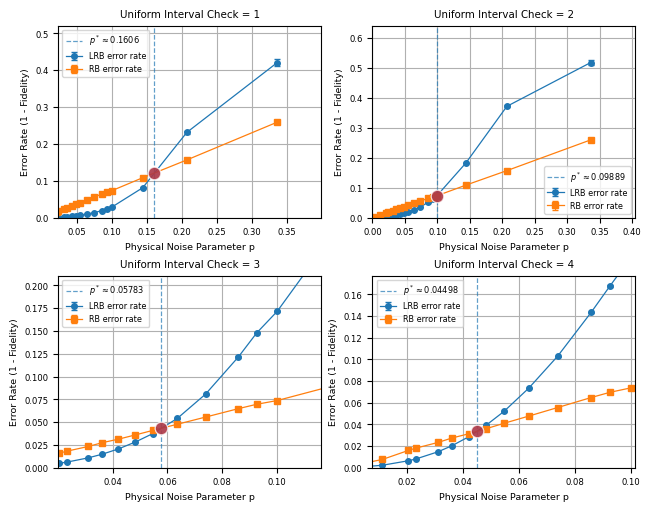

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-threshold-error-vs-p-paper-grid.pdf
[THRESHOLD] Uniform Interval Check = 1: p* = 0.160645 +- 0.000673
[THRESHOLD] Uniform Interval Check = 2: p* = 0.0988896 +- 0.000413
[THRESHOLD] Uniform Interval Check = 3: p* = 0.0578266 +- 0.000246
[THRESHOLD] Uniform Interval Check = 4: p* = 0.0449805 +- 0.000279
[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif_thresholds_summary_monotone_trim_zoom_pwindow.csv
[qgrm_3_1_2] error-rate uncertainty table


,check_num,p,lrb_error_rate,lrb_error_rate_ci_low,lrb_error_rate_ci_high,rb_error_rate,rb_error_rate_ci_low,rb_error_rate_ci_high,lrb_unc_minus,lrb_unc_plus,rb_unc_minus,rb_unc_plus
0,1,0.000034,0.000001,0.000001,0.000001,0.000001,8.790719e-07,0.010524,3.400000e-08,6.800000e-08,2.308244e-07,0.010523
1,1,0.000616,0.000024,0.000024,0.000024,0.001942,9.270207e-07,0.004117,2.747796e-07,2.293586e-07,1.940809e-03,0.002176
2,1,0.011288,0.000581,0.000578,0.000584,0.007631,7.055125e-03,0.008192,3.470294e-06,3.196594e-06,5.756374e-04,0.000561
3,1,0.020613,0.001321,0.001312,0.001330,0.015978,1.555499e-02,0.016483,9.452163e-06,8.964603e-06,4.234817e-04,0.000505
4,1,0.023357,0.001591,0.001581,0.001601,0.018146,1.771793e-02,0.018573,1.014067e-05,9.337094e-06,4.281646e-04,0.000427
...,...,...,...,...,...,...,...,...,...,...,...,...
67,4,0.092552,0.167682,0.167070,0.168297,0.069583,6.927522e-02,0.069908,6.111573e-04,6.149333e-04,3.077120e-04,0.000325
68,4,0.100000,0.193919,0.193232,0.194534,0.073674,7.342690e-02,0.073954,6.876373e-04,6.149120e-04,2.472320e-04,0.000280
69,4,0.143845,0.355895,0.354712,0.357078,0.108520,1.081244e-01,0.108921,1.183723e-03,1.182656e-03,3.956267e-04,0.000401
70,4,0.206914,0.513603,0.512577,0.514716,0.156801,1.563079e-01,0.157251,1.025237e-03,1.113728e-03,4.931200e-04,0.000450


[qgrm_3_1_2] pseudo-threshold uncertainty table


,check_num,threshold_p,threshold_p_std_boot,threshold_p_ci_low,threshold_p_ci_high,threshold_unc_minus,threshold_unc_plus
0,1,0.160645,0.000673,0.159994,0.161345,0.000650,0.000700
1,2,0.098890,0.000413,0.098489,0.099339,0.000400,0.000449
2,3,0.057827,0.000246,0.057575,0.058059,0.000252,0.000233
3,4,0.044981,0.000279,0.044709,0.045277,0.000271,0.000297


('c:\\Users\\Sohan XPS17\\OneDrive - University of California, Davis\\Documents\\UC Davis\\Kim Group\\LBNL\\LRB-Simulations-sdim\\LRB-experiment-data-slurm\\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\\plots\\unif_lrb_vs_rb_table_all_mixed_fits.csv',
 'c:\\Users\\Sohan XPS17\\OneDrive - University of California, Davis\\Documents\\UC Davis\\Kim Group\\LBNL\\LRB-Simulations-sdim\\LRB-experiment-data-slurm\\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\\plots\\unif_thresholds_summary_monotone_trim_zoom_pwindow.csv')

In [11]:
qgrm_table_csv = qgrm_plotter.build_unif_lrb_vs_rb_table_mixed_fits(
    write_per_check_tables=True,
    check_min=unif_check_min,
    check_max=4,
    bootstrap_reps=threshold_config.bootstrap_reps_error,
    bootstrap_ci_level=threshold_config.bootstrap_ci_level,
    bootstrap_use_sem=threshold_config.bootstrap_use_sem,
    bootstrap_seed=threshold_config.bootstrap_seed,
)
qgrm_summary_csv = qgrm_plotter.plot_all_unif_threshold_graphs(
    threshold_config=threshold_config,
    table_csv_path=qgrm_table_csv,
    show=True,
    check_min=unif_check_min,
    check_max=4,
)

qgrm_uncertainty_table = show_error_rate_uncertainty_table(
    qgrm_table_csv,
    label="qgrm_3_1_2",
)
qgrm_pseudo_threshold_table = show_pseudo_threshold_uncertainty_table(
    qgrm_summary_csv,
    label="qgrm_3_1_2",
    check_min=unif_check_min,
    check_max=unif_check_max,
)

qgrm_table_csv, qgrm_summary_csv


### 3.4 Pseudo-threshold trend vs interval check (QGRM)

Generates the QGRM pseudo-threshold trend plot under the same controls used in the folded-qutrit section.


[PSEUDO] Uniform Interval Check = 1: p* = 0.160645 +- 0.000673
[PSEUDO] Uniform Interval Check = 2: p* = 0.0988896 +- 0.000413
[PSEUDO] Uniform Interval Check = 3: p* = 0.0578266 +- 0.000246
[PSEUDO] Uniform Interval Check = 4: p* = 0.0449805 +- 0.000279
[FIT] fit disabled by do_fit=False.


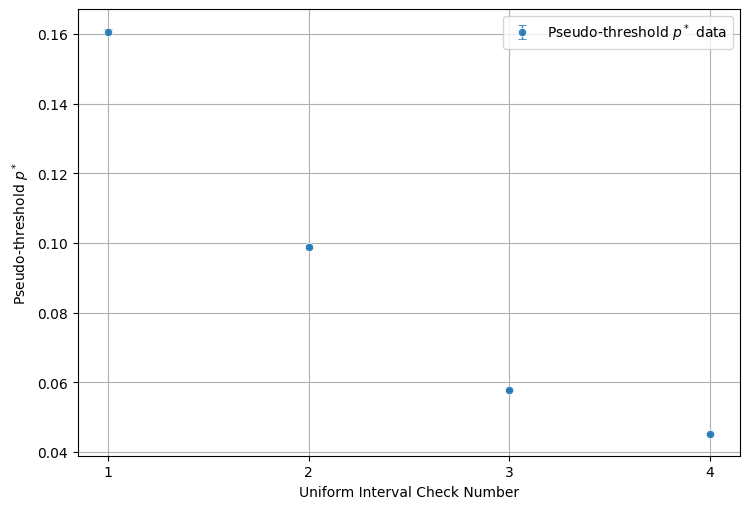

[OK] wrote c:\Users\Sohan XPS17\OneDrive - University of California, Davis\Documents\UC Davis\Kim Group\LBNL\LRB-Simulations-sdim\LRB-experiment-data-slurm\Run-2026-02-18-19-45-33-qgrm_3_1_2/results\plots\unif-1-to-4-pseudo-threshold-vs-interval-check-fit.pdf


In [12]:
qgrm_pseudo_fit_pdf = qgrm_plotter.plot_unif_pseudo_thresholds_vs_interval_check(
    check_min=unif_check_min,
    check_max=4,
    do_fit=pseudo_do_fit,
    fit_model=pseudo_fit_model,
    fit_degree=pseudo_fit_degree,
    paper_mode=paper_plot_config.enabled,
    show=True,
)


## 4. Reading guide for final outputs

When reviewing results, prioritize:

- Threshold position: where each code crosses your practical target regime
- Uncertainty width: narrower confidence intervals indicate more stable estimates
- Cross-check consistency: monotone and smooth behavior across interval checks

A practical comparison starts with the two summary CSV paths returned in Sections 2.3 and 3.3.
